In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('customer_segmentation.csv')


In [ ]:
print("Data Info:")
print(df.info())
print("\nData Description:")
print(df.describe(include='all'))
print("\nMissing Values:")
print(df.isnull().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

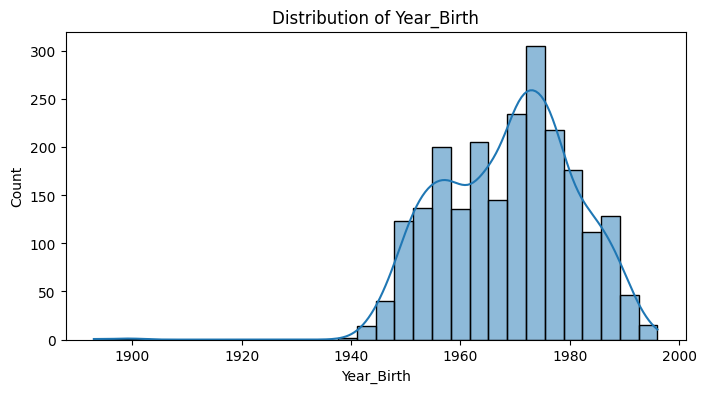

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Year_Birth'], bins=30, kde=True)
plt.title('Distribution of Year_Birth')
plt.show()


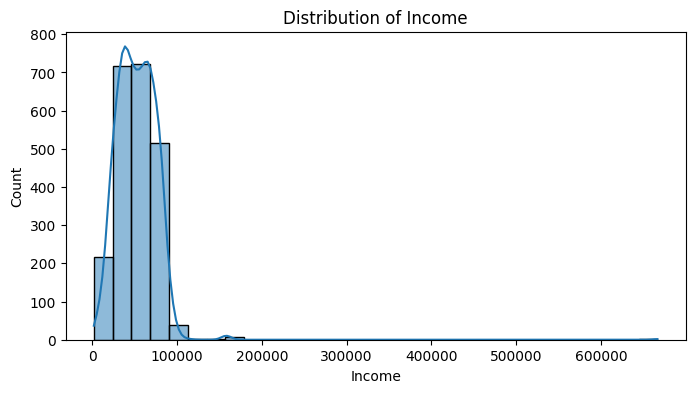

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Income'].dropna(), bins=30, kde=True)
plt.title('Distribution of Income')
plt.show()

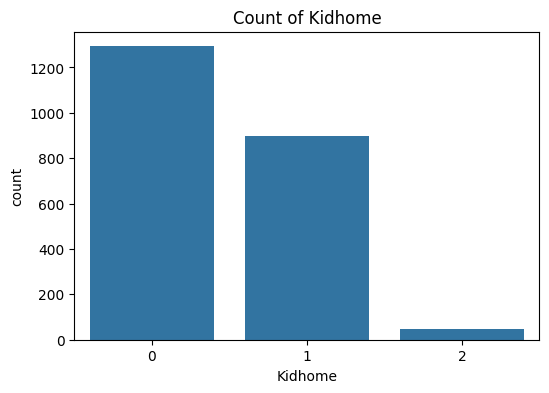

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Kidhome', data=df)
plt.title('Count of Kidhome')
plt.show()

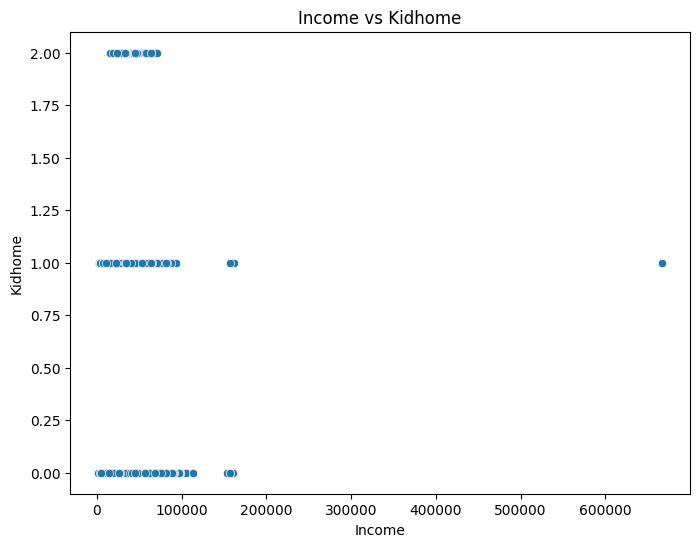

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Income', y='Kidhome', data=df)
plt.title('Income vs Kidhome')
plt.show()


In [ ]:
df['Age'] = 2025 - df['Year_Birth']

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

df['AcceptedCmp_Total'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

df['Total_Mnt'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)


In [ ]:
print("\nMissing values before filling:")
print(df.isnull().sum())


Missing values before filling:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Total_Children          0
AcceptedCmp_Total       0
Total_Mnt               0
dtype: int64


In [ ]:
df['Income'].fillna(df['Income'].mean(), inplace=True)

print("\nMissing values after filling:")
print(df.isnull().sum())


Missing values after filling:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
Total_Children         0
AcceptedCmp_Total      0
Total_Mnt              0
dtype: int64


/tmp/ipython-input-1409543335.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].mean(), inplace=True)


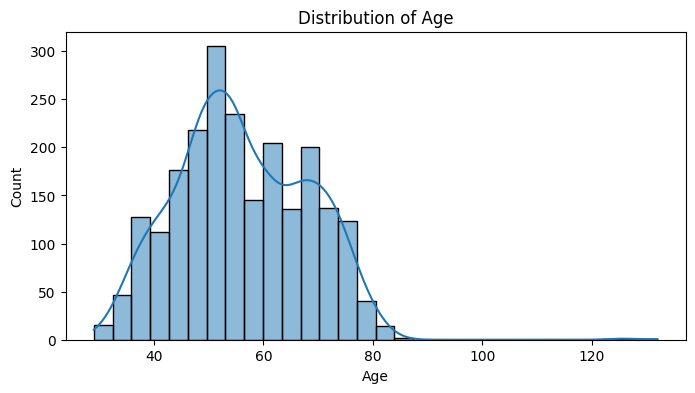

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.show()

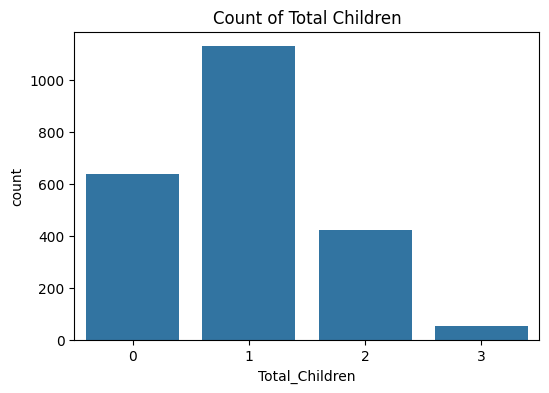

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Total_Children', data=df)
plt.title('Count of Total Children')
plt.show()

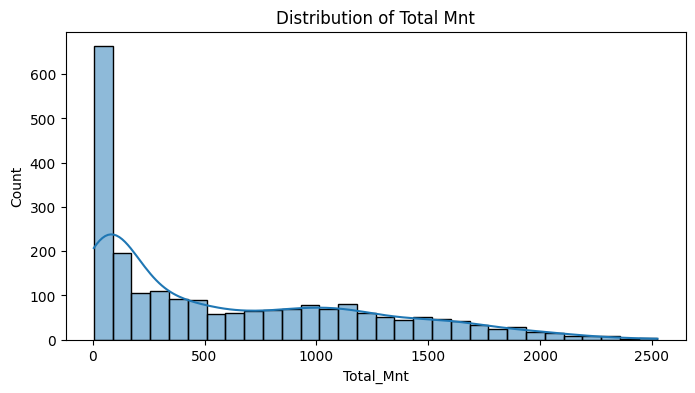

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Total_Mnt'], bins=30, kde=True)
plt.title('Distribution of Total Mnt')
plt.show()


Data after encoding:
     ID  Year_Birth  Education  Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957          2               4  58138.0        0         0   
1  2174        1954          2               4  46344.0        1         1   
2  4141        1965          2               5  71613.0        0         0   
3  6182        1984          2               5  26646.0        1         0   
4  5324        1981          4               3  58293.0        1         0   

   Dt_Customer  Recency  MntWines  ...  AcceptedCmp1  AcceptedCmp2  Complain  \
0           80       58       635  ...             0             0         0   
1          157       38        11  ...             0             0         0   
2          444       26       426  ...             0             0         0   
3          199       26        11  ...             0             0         0   
4          390       94       173  ...             0             0         0   

   Z_CostContact  Z_Revenue 

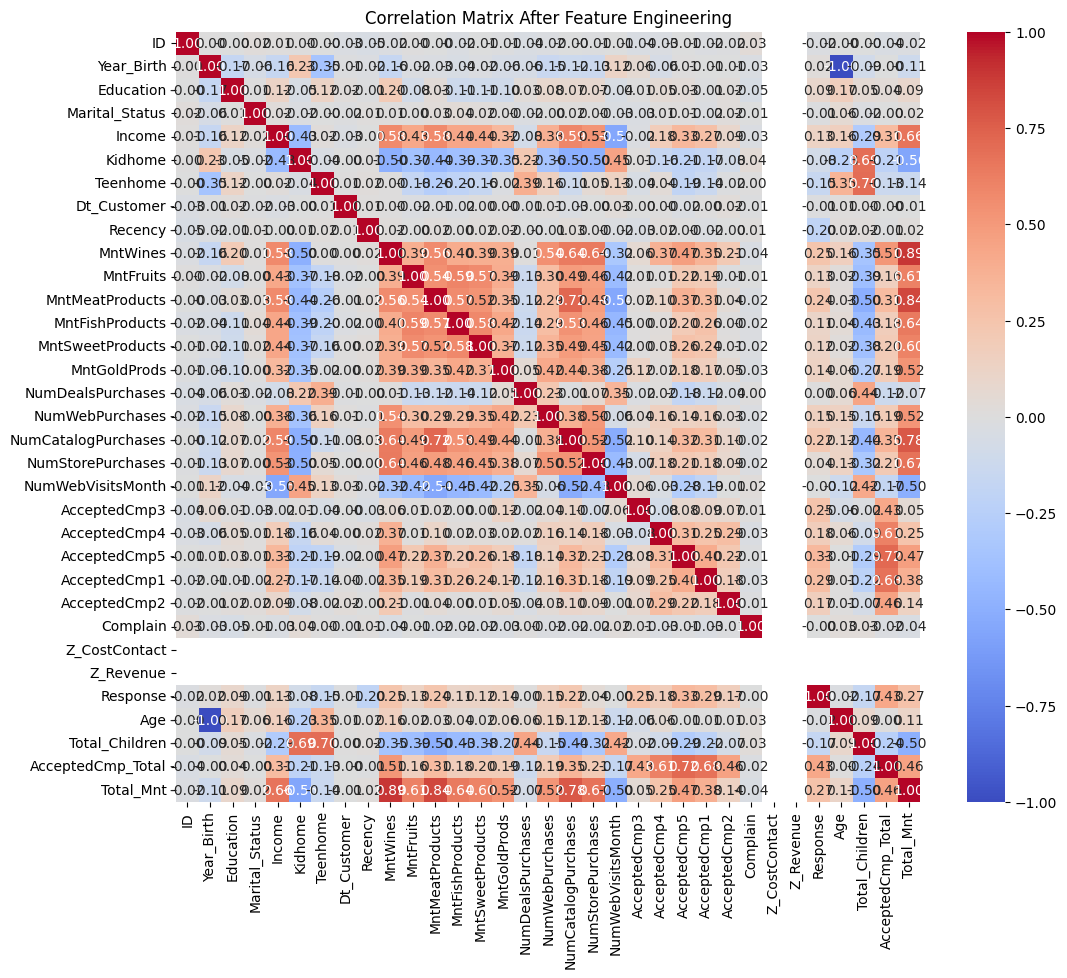

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nData after encoding:")
print(df.head())

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix After Feature Engineering')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nData after encoding:")
print(df.head())


Data after encoding:
     ID  Year_Birth  Education  Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957          2               4  58138.0        0         0   
1  2174        1954          2               4  46344.0        1         1   
2  4141        1965          2               5  71613.0        0         0   
3  6182        1984          2               5  26646.0        1         0   
4  5324        1981          4               3  58293.0        1         0   

   Dt_Customer  Recency  MntWines  ...  AcceptedCmp1  AcceptedCmp2  Complain  \
0           80       58       635  ...             0             0         0   
1          157       38        11  ...             0             0         0   
2          444       26       426  ...             0             0         0   
3          199       26        11  ...             0             0         0   
4          390       94       173  ...             0             0         0   

   Z_CostContact  Z_Revenue 

In [ ]:
features = df.drop(['ID', 'Dt_Customer'], axis=1)


Silhouette Score: 0.12


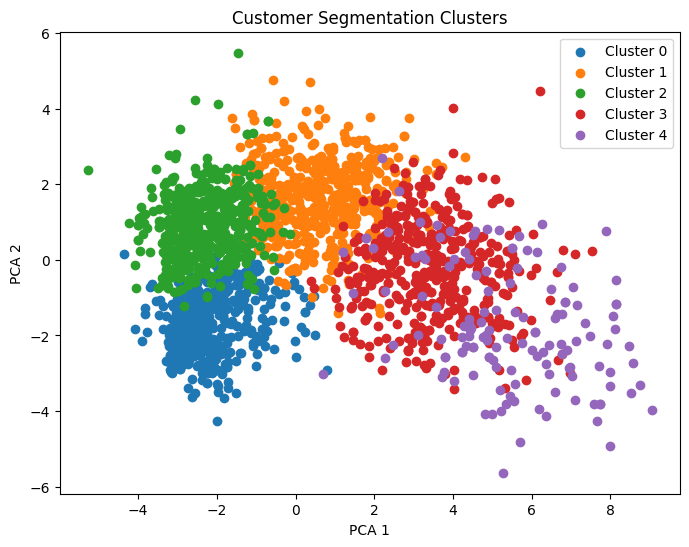

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# تحديد عدد clusters
k = 5  # ممكن تغيري العدد حسب تحليلك

# تدريب KMeans
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# إضافة cluster للـ DataFrame
df['Cluster'] = clusters

# تقييم جودة التقسيم
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.2f}")

# تقليل الأبعاد للرسم
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# رسم clusters
plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(X_pca[clusters == i, 0], X_pca[clusters == i, 1], label=f'Cluster {i}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segmentation Clusters')
plt.legend()
plt.show()

DBSCAN Silhouette Score: 0.16


/tmp/ipython-input-3640556717.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_clusters))


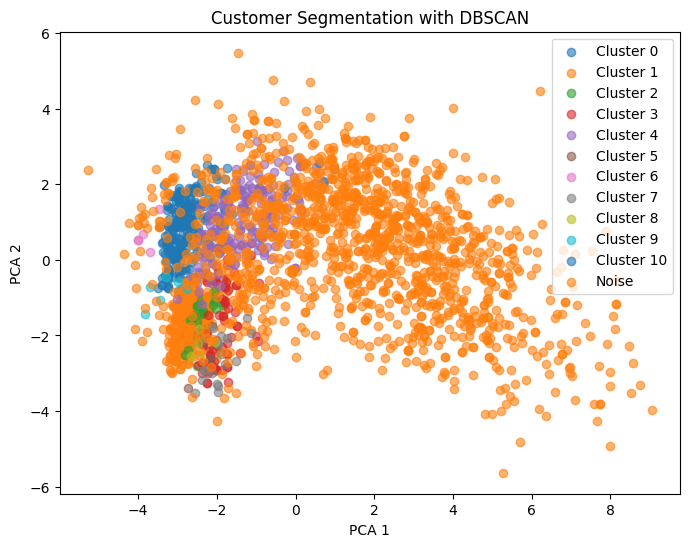

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)  # ممكن تغير eps و min_samples حسب الداتا
clusters_db = dbscan.fit_predict(X_scaled)

# إضافة cluster للـ DataFrame
df['DBSCAN_Cluster'] = clusters_db

# حساب Silhouette Score (نستبعد noise points اللي معمولة -1)
mask = clusters_db != -1
if len(set(clusters_db[mask])) > 1:  # لازم يكون في أكثر من cluster
    score = silhouette_score(X_scaled[mask], clusters_db[mask])
    print(f"DBSCAN Silhouette Score: {score:.2f}")
else:
    print("DBSCAN وجد cluster واحد فقط أو كل النقاط noise")

# تقليل الأبعاد للرسم
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# رسم clusters
plt.figure(figsize=(8,6))
unique_clusters = set(clusters_db)
colors = plt.cm.get_cmap('tab10', len(unique_clusters))

for cluster in unique_clusters:
    plt.scatter(
        X_pca[clusters_db == cluster, 0],
        X_pca[clusters_db == cluster, 1],
        label=f'Cluster {cluster}' if cluster != -1 else 'Noise',
        alpha=0.6
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segmentation with DBSCAN')
plt.legend()
plt.show()